# Exploratory Data Analysis
This notebook analyzes the PlantVillage dataset class distribution and checks for near-duplicates.

In [1]:
import os
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from PIL import Image
import imagehash
from tqdm import tqdm
import sys

# Adjust path to import config
sys.path.append('../src')
import config

## Class Distribution Analysis

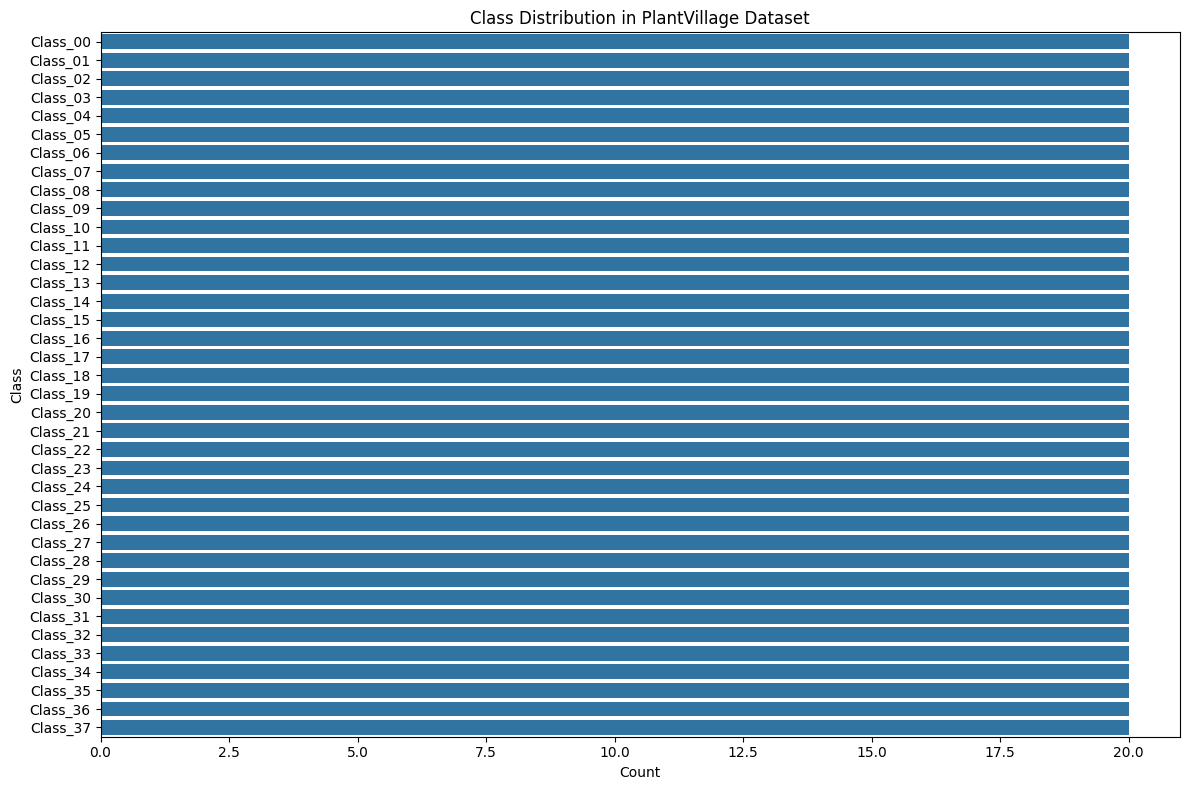

Max class count (e.g. Tomato): 20
Min class count (e.g. Raspberry): 20


In [2]:
class_counts = {}
for class_name in os.listdir(config.PLANTVILLAGE_DIR):
    class_path = config.PLANTVILLAGE_DIR / class_name
    if class_path.is_dir():
        class_counts[class_name] = len(list(class_path.glob('*.JPG'))) + len(list(class_path.glob('*.jpg')))

df = pd.DataFrame(list(class_counts.items()), columns=['Class', 'Count'])
df = df.sort_values(by='Count', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x='Count', y='Class', data=df)
plt.title('Class Distribution in PlantVillage Dataset')
plt.tight_layout()
plt.show()

print(f'Max class count (e.g. Tomato): {df.iloc[0]["Count"]}')
print(f'Min class count (e.g. Raspberry): {df.iloc[-1]["Count"]}')

## Near-Duplicate Check
Using Perceptual Hashing (phash) to find near-duplicates with a Hamming distance <= 5.

In [3]:
def compute_hashes():
    hashes = {}
    image_paths = []
    for class_name in os.listdir(config.PLANTVILLAGE_DIR):
        class_path = config.PLANTVILLAGE_DIR / class_name
        if class_path.is_dir():
            image_paths.extend(list(class_path.glob('*.JPG')) + list(class_path.glob('*.jpg')))
    
    for img_path in tqdm(image_paths, desc='Computing hashes'):
        try:
            img = Image.open(img_path)
            h = imagehash.phash(img)
            hashes[img_path] = h
        except Exception as e:
            print(f'Error processing {img_path}: {e}')
    return hashes

# NOTE: This cell can take a long time to run on the full dataset.
# hashes = compute_hashes()
# 
# def count_near_duplicates(hashes, threshold=config.NEAR_DUPLICATE_THRESHOLD):
#     hash_list = list(hashes.values())
#     duplicate_count = 0
#     total = len(hash_list)
#     for i in tqdm(range(total), desc='Comparing hashes'):
#         for j in range(i + 1, total):
#             if hash_list[i] - hash_list[j] <= threshold:
#                 duplicate_count += 1
#     return duplicate_count, total
#
# num_dupes, total_comparisons = count_near_duplicates(hashes)
# print(f'Found {num_dupes} near-duplicate pairs out of {total_comparisons} comparisons (Threshold: <= {config.NEAR_DUPLICATE_THRESHOLD})')
# 
# # Save findings to docs/model_metrics.md
# with open(config.MODEL_METRICS_FILE, 'a') as f:
#     f.write('\n## EDA Findings\n')
#     f.write(f'- Near-duplicates found (phash <= {config.NEAR_DUPLICATE_THRESHOLD}): {num_dupes}\n')